In [ ]:
# ==============================
# 0. Setup
# ==============================
!pip install transformers datasets torch scikit-learn accelerate -q

import os
os.environ["WANDB_DISABLED"] = "true"   # disable wandb logging

import numpy as np
import pandas as pd
import torch
import re

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, f1_score
from sklearn.preprocessing import LabelEncoder

from transformers import BertTokenizerFast, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

from torch.nn import CrossEntropyLoss

# ==============================
# 1. Load Data
# ==============================
df = pd.read_csv("tweets_ready_bert.csv", sep=",")   # expected columns: ["tweets", "polarity"]

# Skip all preprocessing steps

# Drop missing values if any
df = df.dropna(subset=["tweets", "polarity"])

# ==============================
# 1.1 Encode Labels
# ==============================
label_encoder = LabelEncoder()
df["polarity"] = label_encoder.fit_transform(df["polarity"])

num_labels = int(len(label_encoder.classes_))
id2label = {int(i): str(label) for i, label in enumerate(label_encoder.classes_)}
label2id = {str(label): int(i) for label, i in id2label.items()}

# Drop any remaining NaNs (in case of encoding issues)
df = df.dropna(subset=["polarity"])

# ==============================
# 1.2 Train-Test Split
# ==============================
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["tweets"], df["polarity"], test_size=0.2, random_state=42, stratify=df["polarity"]
)

# Compute class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)
print("Class weights:", class_weights)

class_weights = torch.tensor(class_weights, dtype=torch.float)

# ==============================
# 2. Tokenizer & Datasets
# ==============================
tokenizer = BertTokenizerFast.from_pretrained("indobenchmark/indobert-base-p2")

def tokenize(batch):
    return tokenizer(
        batch["tweets"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_df = pd.DataFrame({
    "tweets": train_texts.astype(str),
    "labels": train_labels.astype(int)
})
test_df  = pd.DataFrame({
    "tweets": test_texts.astype(str),
    "labels": test_labels.astype(int)
})

train_dataset = Dataset.from_pandas(train_df)
test_dataset  = Dataset.from_pandas(test_df)

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset  = test_dataset.map(tokenize, batched=True)

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# ==============================
# 3. Model
# ==============================
model = BertForSequenceClassification.from_pretrained(
    "indobenchmark/indobert-base-p2",
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

# Optional: Freeze bottom 4 layers (fine-tuning trick)
for name, param in model.bert.named_parameters():
    if "encoder.layer" in name and int(name.split(".")[2]) < 4:
        param.requires_grad = False

print("✅ IndoBERT model ready")

# ==============================
# 4. Weighted Trainer
# ==============================
class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

# ==============================
# 5. Metrics
# ==============================
def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)

    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="weighted"
    )
    f1_macro = f1_score(
        labels, preds, average="macro"
    )

    return {
        "accuracy": acc,
        "precision_weighted": precision,
        "recall_weighted": recall,
        "f1_weighted": f1,
        "f1_macro": f1_macro
    }

# ==============================
# 6. Training Arguments
# ==============================
training_args = TrainingArguments(
    output_dir="./results",
    do_train=True,
    do_eval=True,
    save_steps=500,
    logging_steps=50,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_dir="./logs",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none"
)

# ==============================
# 7. Trainer
# ==============================
trainer = WeightedTrainer(
    class_weights=class_weights,
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

# ==============================
# 8. Train
# ==============================
trainer.train()

# ==============================
# 9. Evaluate
# ==============================
eval_results = trainer.evaluate()
print("\nEvaluation Results:")
print(f"Accuracy: {eval_results['eval_accuracy']:.4f}")
print(f"F1 Macro: {eval_results['eval_f1_macro']:.4f}\n")

preds = trainer.predict(test_dataset)
y_pred = np.argmax(preds.predictions, axis=1)
y_true = preds.label_ids

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=[str(c) for c in label_encoder.classes_], digits=4))

Class weights: [1.03068933 1.3833967  0.76515948]


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted,F1 Macro
1,0.893100,0.682205,0.717949,0.716951,0.717949,0.715073,0.698136
2,0.631000,0.651865,0.712454,0.712627,0.712454,0.712379,0.694111
3,0.412900,0.715029,0.727106,0.732185,0.727106,0.726438,0.708535
4,0.267800,0.808068,0.732601,0.733460,0.732601,0.732636,0.715161
5,0.156900,0.878794,0.728938,0.733609,0.728938,0.730677,0.714269


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument i


Evaluation Results:
Accuracy: 0.7326
F1 Macro: 0.7152



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Classification Report:
              precision    recall  f1-score   support

           0     0.6807    0.6420    0.6608       176
           1     0.6338    0.6818    0.6569       132
           2     0.8277    0.8277    0.8277       238

    accuracy                         0.7326       546
   macro avg     0.7141    0.7172    0.7152       546
weighted avg     0.7335    0.7326    0.7326       546



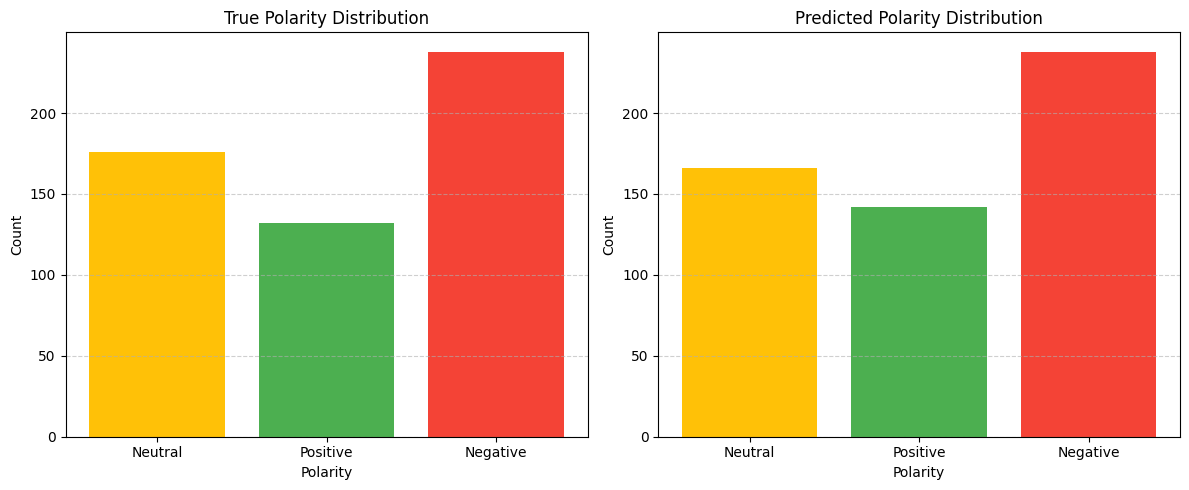

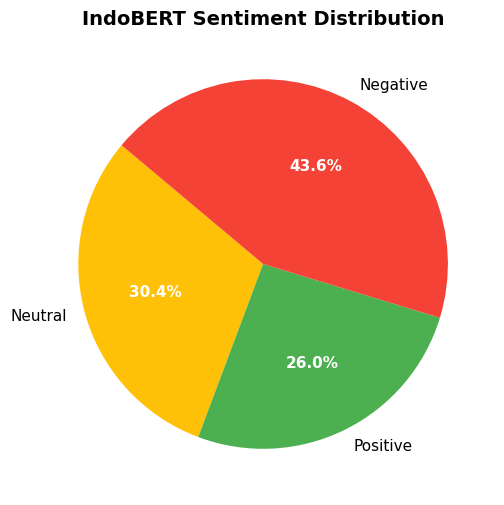

In [ ]:
# ==============================
# 10. Polarity Distribution Visualization
# ==============================
import matplotlib.pyplot as plt

# Label mapping (based on your encoding)
label_map = {0: "Neutral", 1: "Positive", 2: "Negative"}

# Decode numeric predictions to their string labels
y_true_labels = [label_map[label] for label in y_true]
y_pred_labels = [label_map[label] for label in y_pred]

# Count distribution
true_counts = pd.Series(y_true_labels).value_counts()[["Neutral", "Positive", "Negative"]]
pred_counts = pd.Series(y_pred_labels).value_counts()[["Neutral", "Positive", "Negative"]]

# === Bar Chart (True vs Predicted) ===
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#FFC107', '#4CAF50', '#F44336']  # Neutral=Yellow, Positive=Green, Negative=Red

# True distribution
axes[0].bar(true_counts.index, true_counts.values, color=colors)
axes[0].set_title("True Polarity Distribution")
axes[0].set_xlabel("Polarity")
axes[0].set_ylabel("Count")
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Predicted distribution
axes[1].bar(pred_counts.index, pred_counts.values, color=colors)
axes[1].set_title("Predicted Polarity Distribution")
axes[1].set_xlabel("Polarity")
axes[1].set_ylabel("Count")
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# === Pie Chart (Predicted) ===
plt.figure(figsize=(6,6))
wedges, texts, autotexts = plt.pie(
    pred_counts.values,
    labels=pred_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    textprops={'color': 'black', 'fontsize': 11}
)

# Make percentage text white and bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.title("IndoBERT Sentiment Distribution", fontsize=14, fontweight='bold')
plt.show()
